In [23]:
from typing import Dict, List
import h5py
from math import sqrt
import numpy as np
import scipy as sp
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
import networkx as nx
import cirq
import openfermion as of
import qiskit
from quimb.tensor import DMRG
from quimb_tebd import (
    pauli_sum_to_mpo, get_drmg_ground_state, trotter_circuit_from_psum,
    energy_vs_d, total_number_qubit_operator, get_evolved_states,
    fill_subspace_matrices_mps, mps_to_vector, exact_evolved_states,
    fill_subspace_matrices_vectors
)

In [24]:
def tfim_hamiltonian(qubit_graph: nx.Graph, j: float, g: float) -> cirq.PauliSum:
    """Hamiltonian for the transverse-field Ising model.
    H = -J (sum_ij Z_i Z_j + g sum_j X_j)"""

    qs = cirq.LineQubit.range(len(qubit_graph.nodes()))
    h = cirq.PauliSum()
    for i in qubit_graph.nodes():
        h += -j * g * cirq.X.on(qs[i])
        for k in qubit_graph.neighbors(i):
            h += -j * cirq.Z.on(qs[i]) * cirq.Z.on(qs[k])
    return h

In [25]:
l = 3
j = 1.0
g = 2.0
mpo_bond = 100
bond_dims = [2, 4, 6, 8]
d = 20
tau = 0.1
steps = 10
eps = 1e-10

grid_graph = nx.grid_graph(dim=(l,l))
grid_graph = nx.convert_node_labels_to_integers(grid_graph)
hamiltonian = tfim_hamiltonian(grid_graph, j, g)
ham_mpo = pauli_sum_to_mpo(hamiltonian, hamiltonian.qubits, mpo_bond)

# Get energy by exact diagonalization

In [26]:
ham_matrix = hamiltonian.matrix()
eigvals, eigvecs = sp.linalg.eigh(ham_matrix)
energy_exact = np.min(eigvals)
print(f"Exact energy = {energy_exact}")

Exact energy = -27.6415805162409


## Do DMRG at various bond dimensions

In [27]:
dmrg_ground_states = []
dmrg_energies = []
for chi_dmrg in bond_dims:
    print(f"chi = {chi_dmrg}")
    dmrg = DMRG(ham_mpo, chi_dmrg)
    converged = dmrg.solve()
    if not converged:
        print("DMRG did not converge!")
    ground_energy = dmrg.energy.real
    print(f"Got energy {ground_energy}")
    ground_state = dmrg.state
    dmrg_ground_states.append(ground_state.copy())
    dmrg_energies.append(ground_energy)

chi = 2
Got energy -27.59098637928648
chi = 4
Got energy -27.625953304432986
chi = 6
Got energy -27.638473829711774
chi = 8
Got energy -27.64150352561345


# Do Krylov at various bond dimensions.

Each starts with the DMRG ground state that has the smallest bond dimension.

In [28]:
# Compile the circuit.
ev_circuit = trotter_circuit_from_psum(hamiltonian, tau, steps)
ev_circuit_transpiled = qiskit.transpile(ev_circuit)

In [29]:
krylov_energies = np.zeros((len(bond_dims), d-1), dtype=float)
ref_state = dmrg_ground_states[0].copy()
for i, chi in enumerate(bond_dims):
    states = get_evolved_states(ev_circuit_transpiled, ref_state, d, chi, None)
    h, s = fill_subspace_matrices_mps(states, ham_mpo)
    energies, num_kept = energy_vs_d(h, s, method="threshold", eps=eps)
    krylov_energies[i, :] = energies

In [30]:
krylov_errs = np.abs(krylov_energies - energy_exact)

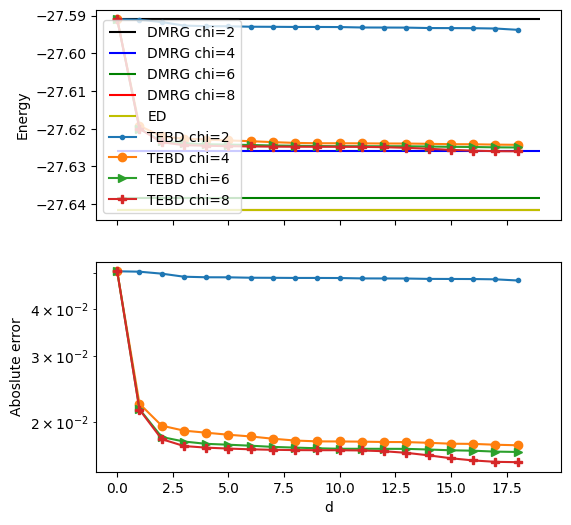

In [32]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(6, 6))
markers = [".", "o", ">", "P"]
colors = ["k", "b", "g", "r"]
for i, chi in enumerate(bond_dims):
    ax[0].hlines(dmrg_energies[i], 0., krylov_energies.shape[1], colors=colors[i], label=f"DMRG chi={chi}")
ax[0].hlines(energy_exact, 0., krylov_energies.shape[1], colors="y", label="ED")
for i, chi in enumerate(bond_dims):
    ax[0].plot(krylov_energies[i, :], marker=markers[i], label=f"TEBD chi={chi}")
    ax[1].plot(krylov_errs[i, :], marker=markers[i], label=f"TEBD chi={chi}")
ax[0].legend()
ax[0].set_ylabel("Energy")
ax[1].set_ylabel("Aboslute error")
ax[1].set_xlabel("d")
ax[1].set_yscale("log")